In [55]:
import cv2
import numpy as np
import matplotlib.image as img
from matplotlib import pyplot as plt

In [91]:
img = cv2.imread('gambar.jpg')

In [92]:
def edge_mask(img,line_size,blur_value):
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  blur = cv2.medianBlur(gray,blur_value)
  edges = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,line_size,blur_value)
  return edges
line_size = 7
blur_value = 7

In [93]:
edges = edge_mask(img,line_size,blur_value)

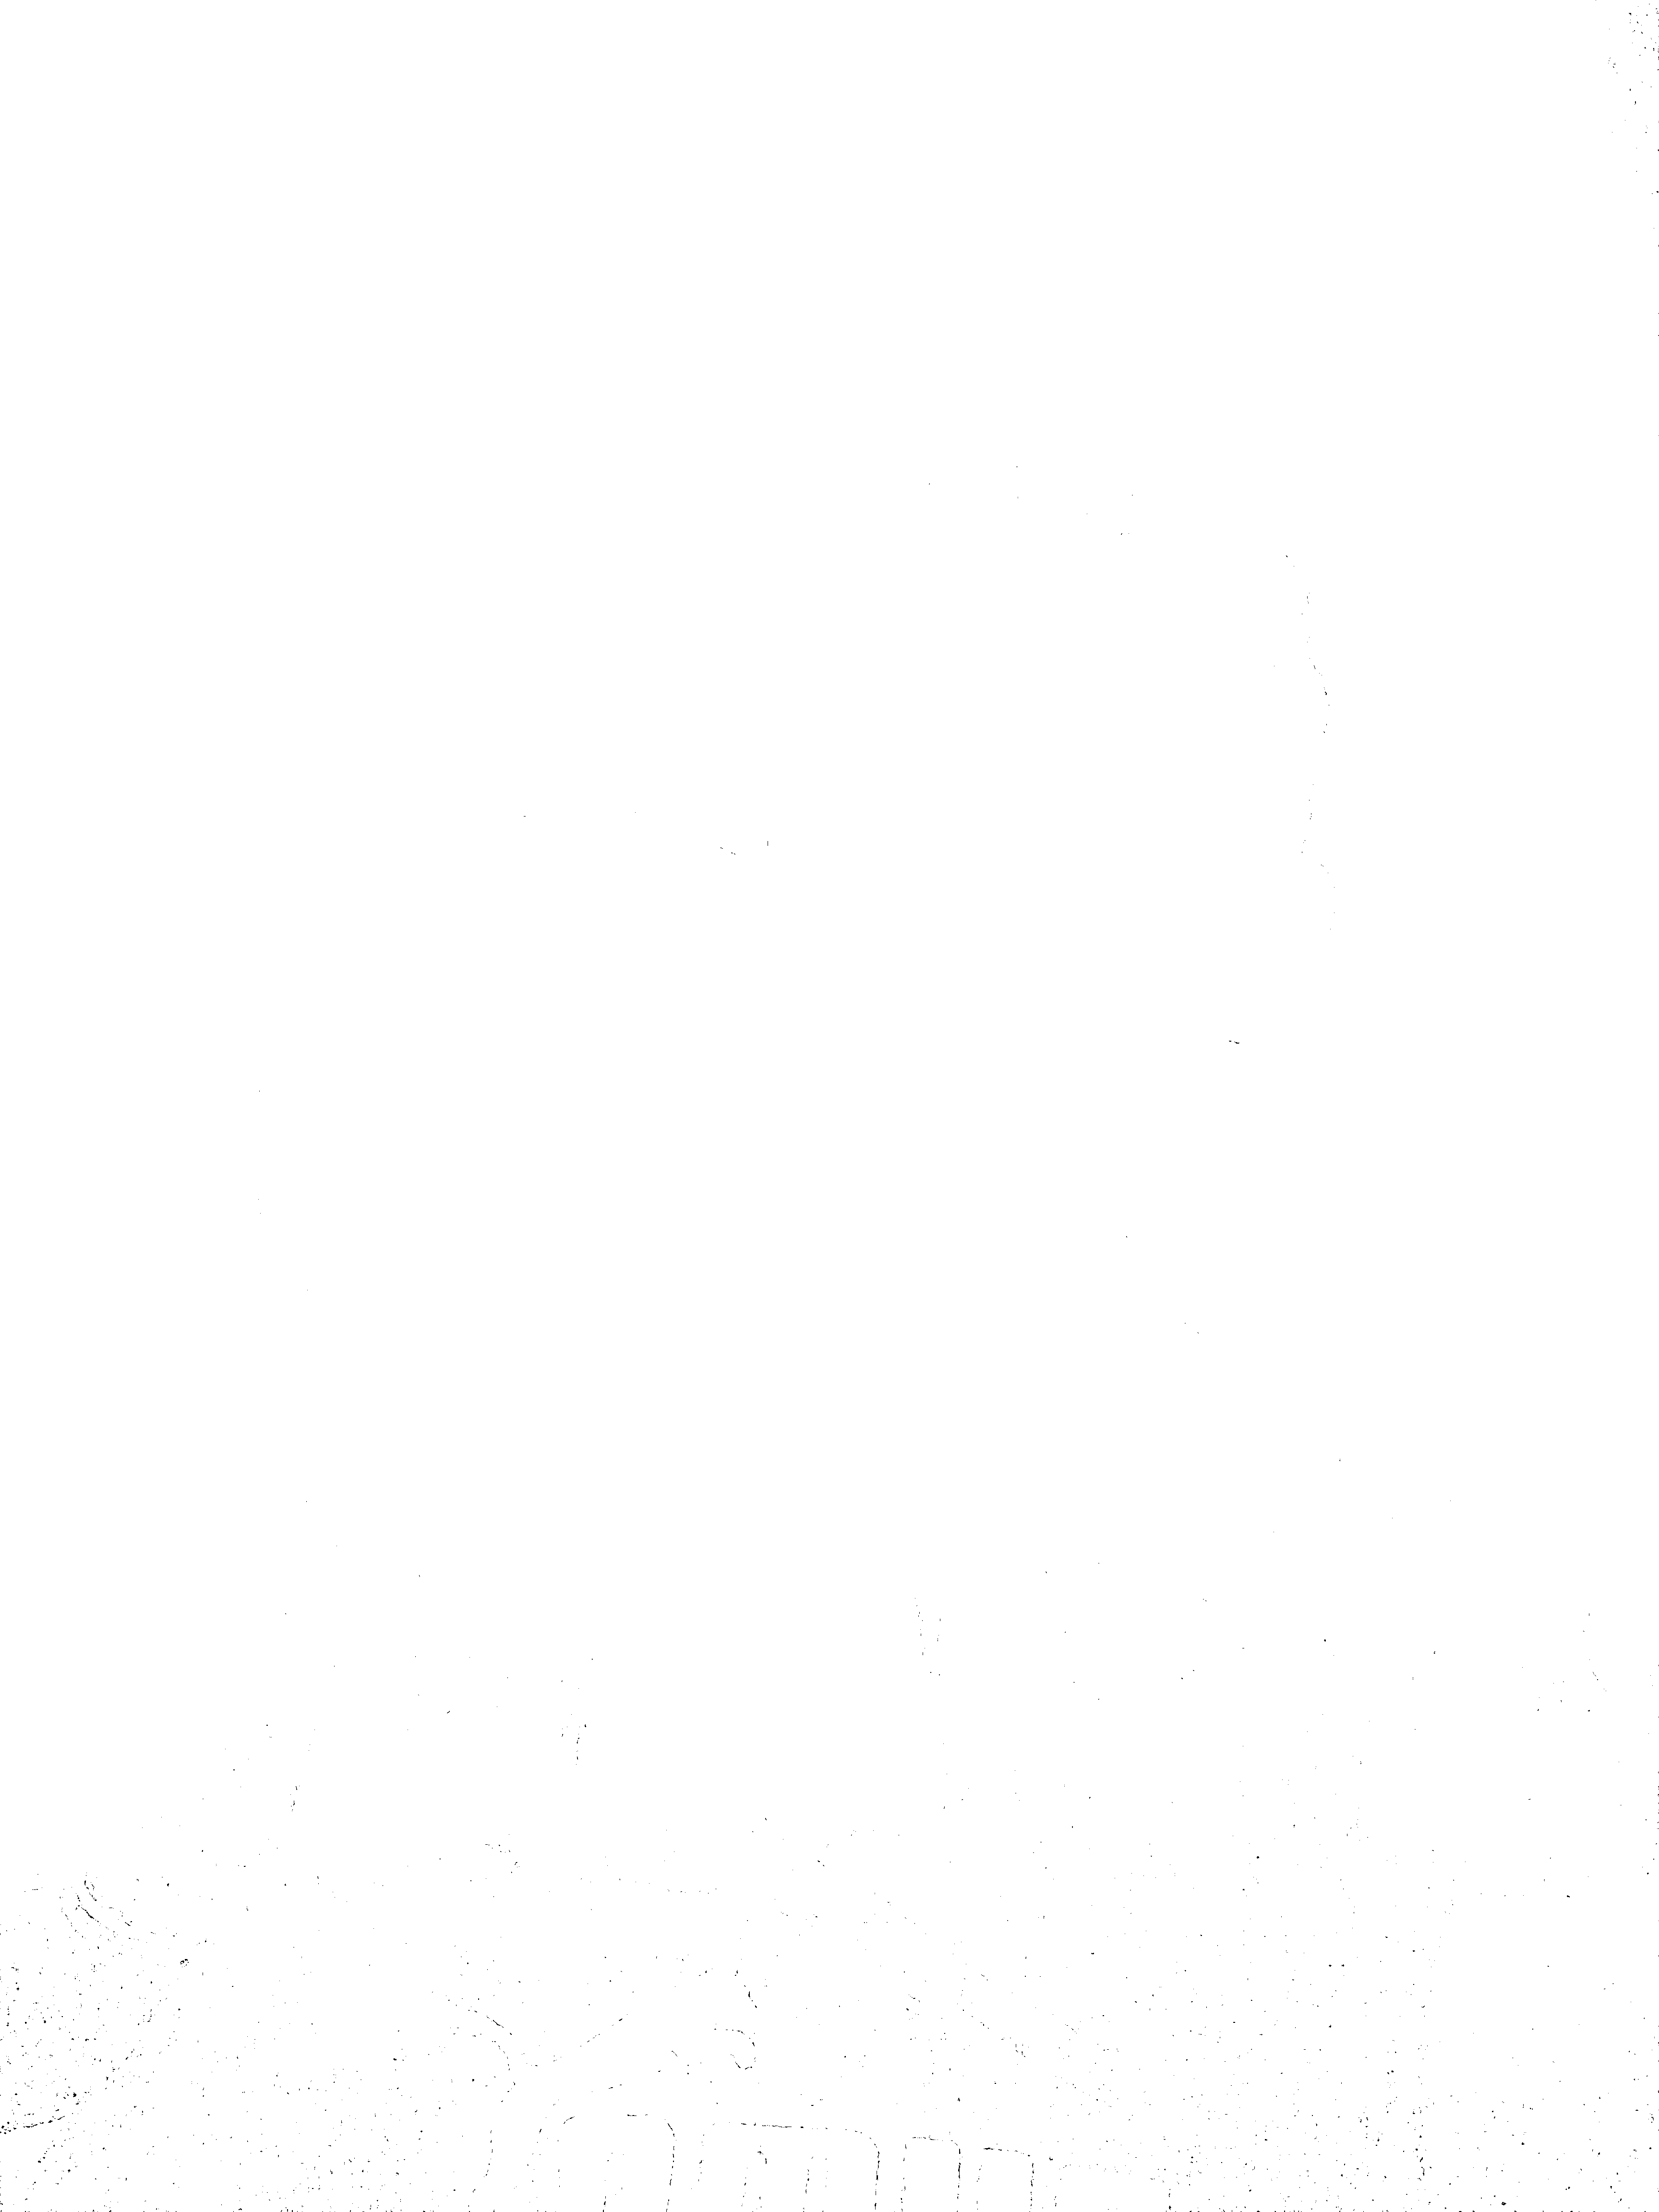

In [94]:
from google.colab.patches import cv2_imshow
cv2_imshow(edges)

In [84]:
total_color = 8
k = total_color

In [85]:
data = np.float32(img).reshape((-1,3))

In [86]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,20,0.001)

In [87]:
ret,label,center = cv2.kmeans(data,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS, cv2.KMEANS_PP_CENTERS)
center = np.uint8(center)
result = center[label.flatten()]
result = result.reshape(img.shape)

In [88]:
blured = cv2.bilateralFilter(result, d=10, sigmaColor=250, sigmaSpace=250)

In [89]:
carton = cv2.bitwise_and(blured,blured,mask=edges)

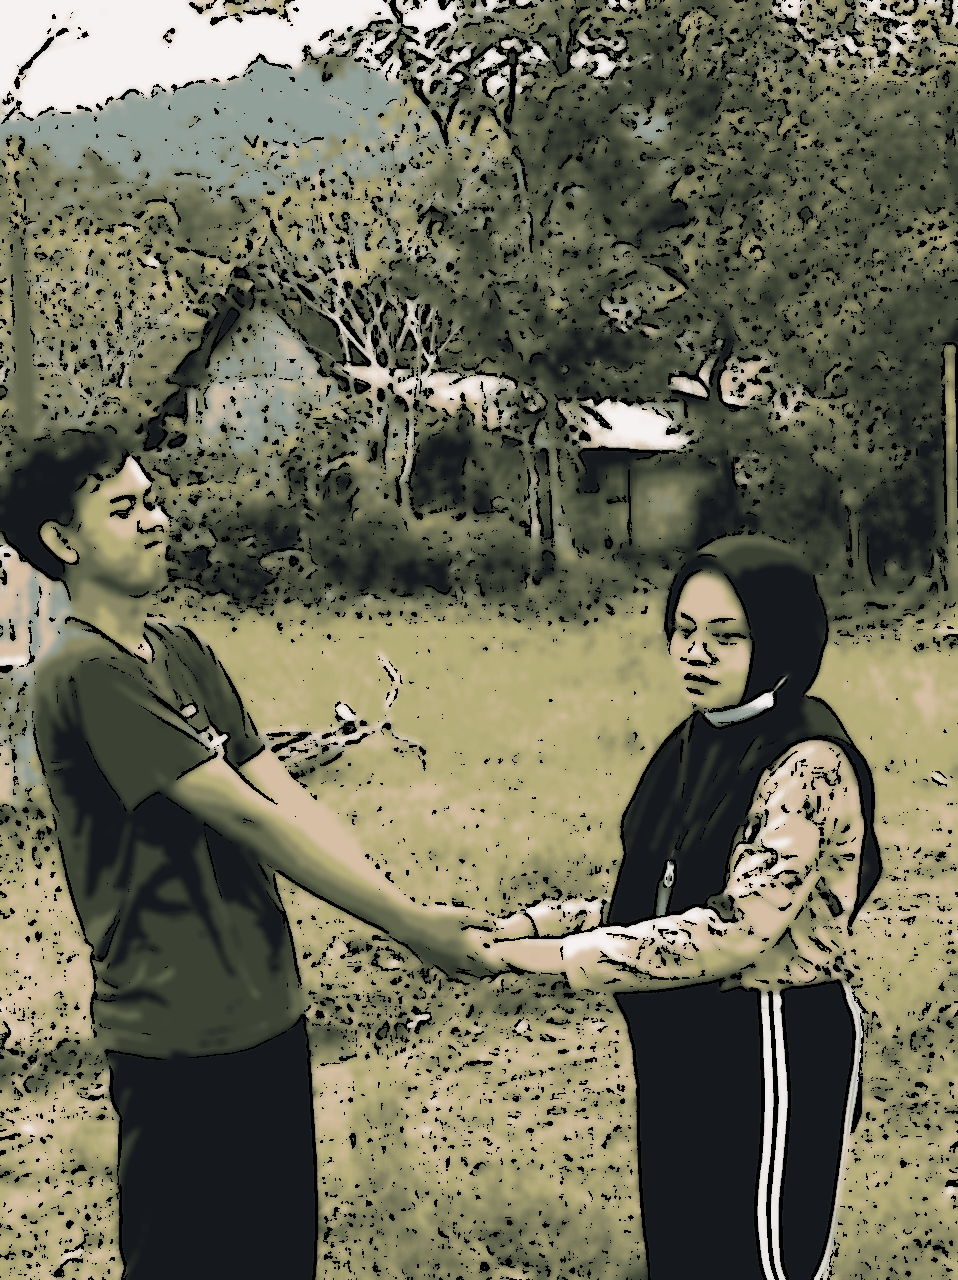

True

In [90]:
from google.colab.patches import cv2_imshow
cv2_imshow(carton)
cv2.imwrite('carton7.jpg',carton)